In [1]:
#pip install geopandas matplotlib contextily

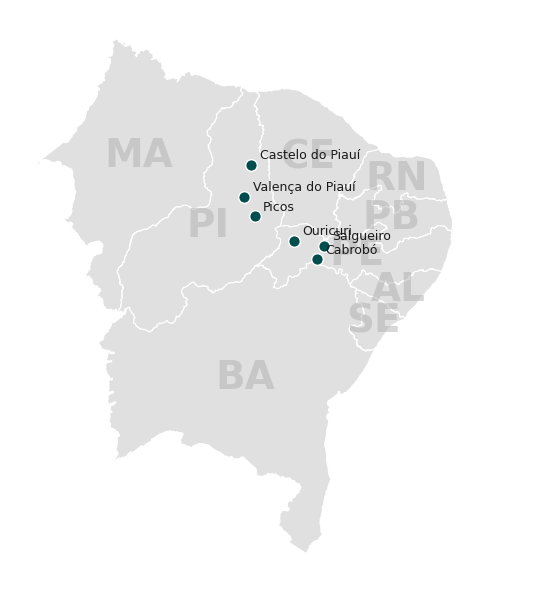

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

# 1. Dados das cidades fornecidas
data = {
    'Cidade': ['Salgueiro', 'Ouricuri', 'Cabrobó', 'Valença do Piauí', 'Castelo do Piauí', 'Picos'],
    'Estado': ['PE', 'PE',  'PE', 'PI', 'PI', 'PI'],
    'lat': [-8.06, -7.89, -8.50, -6.42, -5.35, -7.07],
    'lon': [-39.10, -40.10, -39.32, -41.75, -41.51, -41.40]
}


df = pd.DataFrame(data)
gdf_pontos = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326"
)

# 2. Carregar o mapa do Brasil e filtrar o Nordeste
url_brasil = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brasil = gpd.read_file(url_brasil)

# Certifique-se de que o GeoJSON tem uma coluna com a sigla ou nome (geralmente 'sigla' ou 'name')
# Se o seu arquivo usar 'name', troque 'sigla' por 'name' abaixo.
estados_ne_siglas = ['AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
nordeste = brasil[brasil['sigla'].isin(estados_ne_siglas)].copy() # copy para evitar warnings

# 3. Configuração do Plot
fig, ax = plt.subplots(figsize=(12, 6))

# Camada 1: O mapa base dos estados (Cinza claro)
nordeste.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.8)

# --- NOVA ETAPA: Adicionar Marcas d'Água dos Estados ---
# O segredo é um fontsize grande, alpha baixo e centralização
for _, row in nordeste.iterrows():
    # Pega o centróide do estado
    centroid = row['geometry'].centroid
    # Adiciona a sigla (ou row['name'] se preferir o nome completo)
    ax.text(centroid.x, centroid.y, row['sigla'], fontsize=28, 
            color='#b0b0b0', alpha=0.5, # Cinza claro, 50% transparente
            fontweight='bold', ha='center', va='center', zorder=1)

# Camada 2: Pontos das cidades
gdf_pontos.plot(ax=ax, color='#004d4d', markersize=70, edgecolor='white', zorder=5)

# Camada 3: Nomes das cidades
for x, y, label in zip(gdf_pontos.geometry.x, gdf_pontos.geometry.y, gdf_pontos.Cidade):
    ax.annotate(label, xy=(x, y), xytext=(6, 4), textcoords="offset points", 
                fontsize=9, fontweight='normal', color='#1a1a1a', zorder=10)

# Ajustes estéticos finais
ax.axis('off') # Remove os eixos (coordenadas)
ax.set_aspect('equal') # Mantém a proporção geográfica correta
plt.savefig(f'timeserieslocation.pdf', format='pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()